![](image.jpg)


Dive into the heart of data science with a project that combines healthcare insights and predictive analytics. As a Data Scientist at a top Health Insurance company, you have the opportunity to predict customer healthcare costs using the power of machine learning. Your insights will help tailor services and guide customers in planning their healthcare expenses more effectively.

## Dataset Summary

Meet your primary tool: the `insurance.csv` dataset. Packed with information on health insurance customers, this dataset is your key to unlocking patterns in healthcare costs. Here's what you need to know about the data you'll be working with:

## insurance.csv
| Column    | Data Type | Description                                                      |
|-----------|-----------|------------------------------------------------------------------|
| `age`       | int       | Age of the primary beneficiary.                                  |
| `sex`       | object    | Gender of the insurance contractor (male or female).             |
| `bmi`       | float     | Body mass index, a key indicator of body fat based on height and weight. |
| `children`  | int       | Number of dependents covered by the insurance plan.              |
| `smoker`    | object    | Indicates whether the beneficiary smokes (yes or no).            |
| `region`    | object    | The beneficiary's residential area in the US, divided into four regions. |
| `charges`   | float     | Individual medical costs billed by health insurance.             |



A bit of data cleaning is key to ensure the dataset is ready for modeling. Once your model is built using the `insurance.csv` dataset, the next step is to apply it to the `validation_dataset.csv`. This new dataset, similar to your training data minus the `charges` column, tests your model's accuracy and real-world utility by predicting costs for new customers.

## Let's Get Started!

This project is your playground for applying data science in a meaningful way, offering insights that have real-world applications. Ready to explore the data and uncover insights that could revolutionize healthcare planning? Let's begin this exciting journey!

In [4]:
# Re-run this cell
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Loading the insurance dataset
insurance_data_path = 'insurance.csv'
insurance = pd.read_csv(insurance_data_path)
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19.0,female,27.900,0.0,yes,southwest,16884.924
1,18.0,male,33.770,1.0,no,Southeast,1725.5523
2,28.0,male,33.000,3.0,no,southeast,$4449.462
3,33.0,male,22.705,0.0,no,northwest,$21984.47061
4,32.0,male,28.880,0.0,no,northwest,$3866.8552


In [294]:
# Implement model creation and training here
# Use as many cells as you need
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1272 non-null   float64
 1   sex       1272 non-null   object 
 2   bmi       1272 non-null   float64
 3   children  1272 non-null   float64
 4   smoker    1272 non-null   object 
 5   region    1272 non-null   object 
 6   charges   1284 non-null   object 
dtypes: float64(3), object(4)
memory usage: 73.3+ KB


In [12]:
insurance.describe()

,age,bmi,children
count,1272.000000,1272.000000,1272.000000
mean,35.214623,30.560550,0.948899
std,22.478251,6.095573,1.303532
min,-64.000000,15.960000,-4.000000
25%,24.750000,26.180000,0.000000
50%,38.000000,30.210000,1.000000
75%,51.000000,34.485000,2.000000
max,64.000000,53.130000,5.000000


<AxesSubplot: xlabel='count', ylabel='sex'>

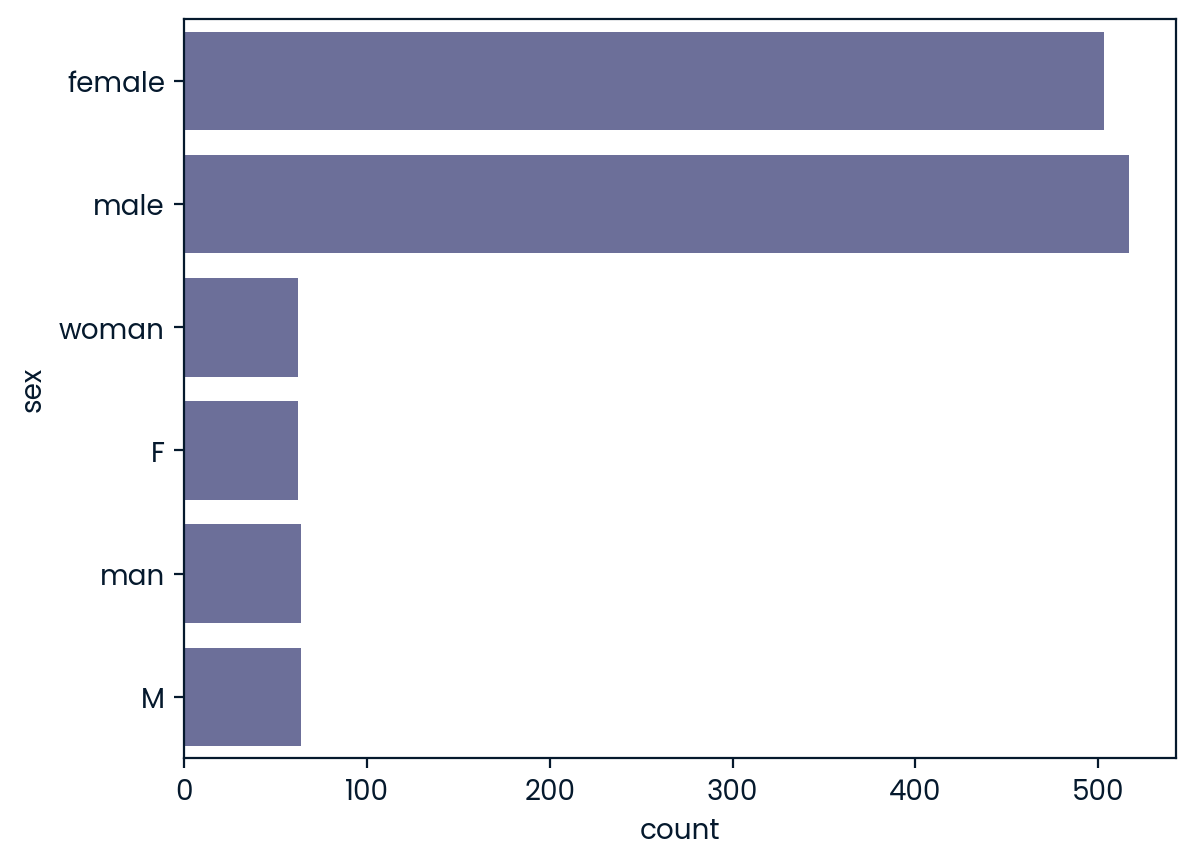

In [10]:
sns.countplot(insurance.sex)

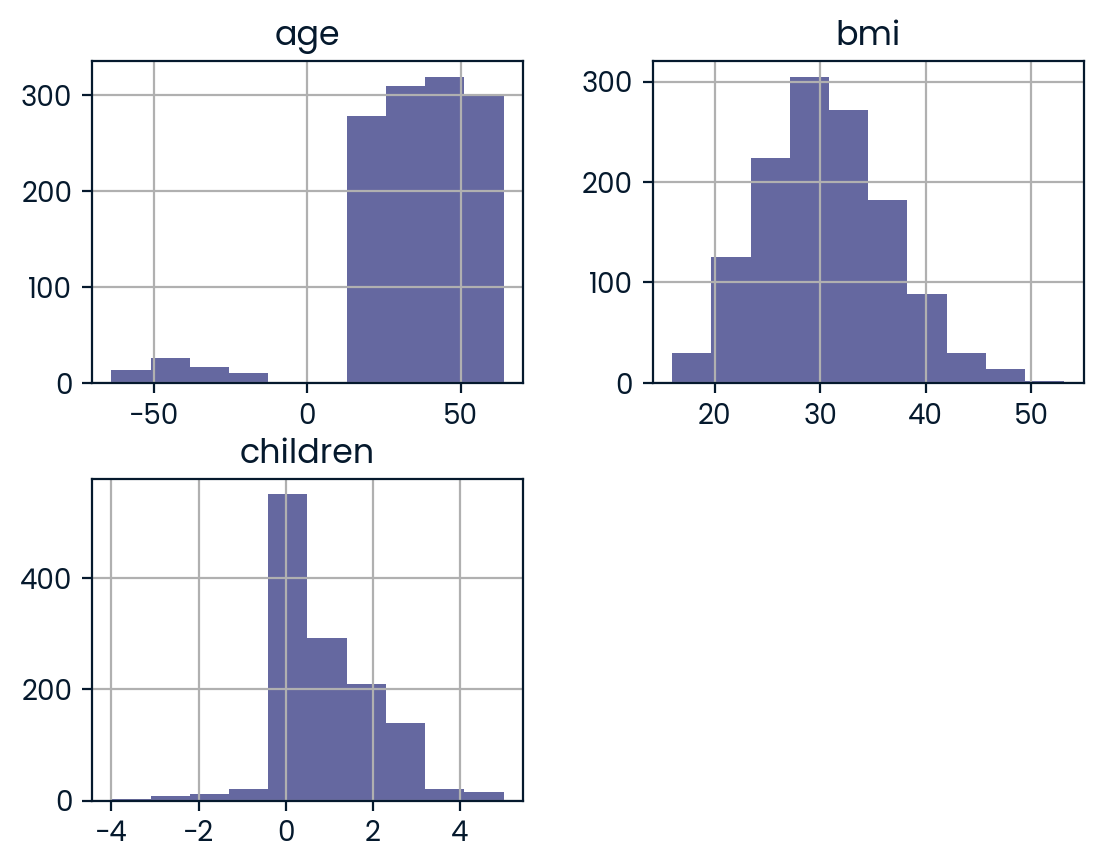

In [8]:
insurance.hist()
plt.show()

<AxesSubplot: >

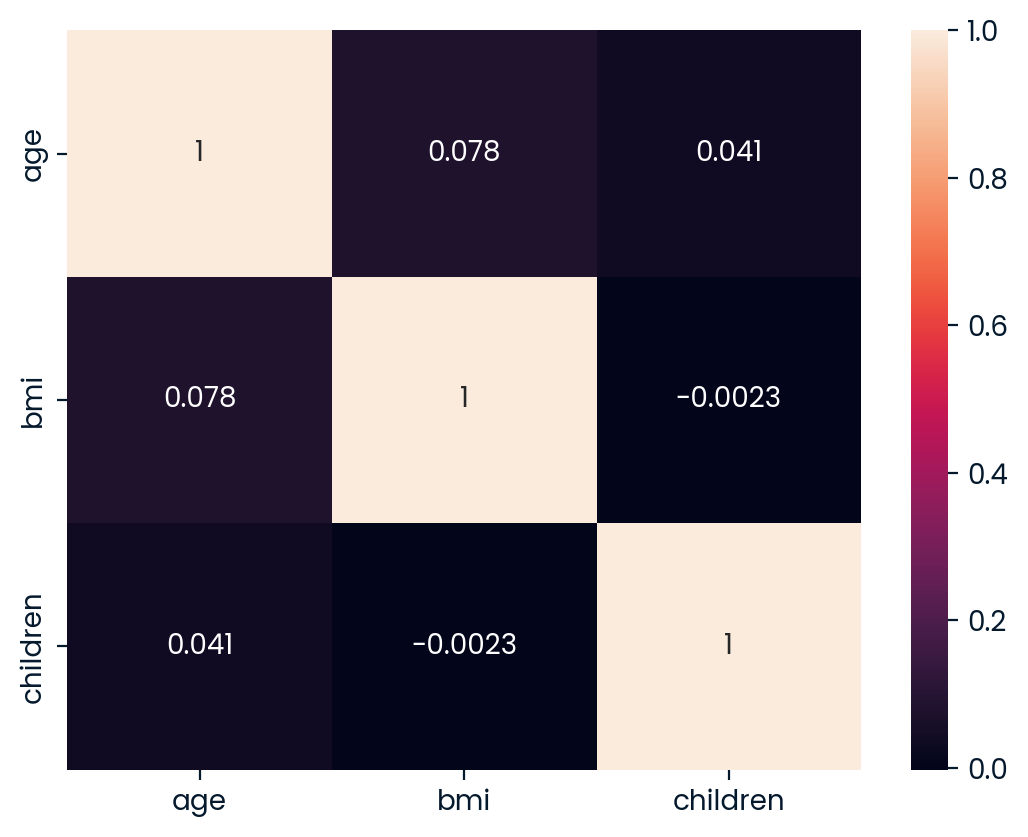

In [11]:
sns.heatmap(insurance.corr(), annot=True)

In [295]:
def cleandf(df):

    df_clean = df.copy()
    
    if 'charges' in df_clean.columns:
        df_clean['charges'] = df_clean['charges'].astype(str).str.replace('$', '', regex=False)
        df_clean['charges'] = pd.to_numeric(df_clean['charges'], errors='coerce')

    if 'sex' in df_clean.columns:
        df_clean['sex'] = df_clean['sex'].replace({'M': 'male', 'man': 'male', 'F': 'female', 'woman': 'female'})

    if 'region' in df_clean.columns:
        df_clean["region"] = df_clean["region"].str.lower()

    if 'age' in df_clean.columns:
        df_clean = df_clean[df_clean["age"] > 0]

    if 'children' in df_clean.columns:
        df_clean.loc[df_clean["children"] < 0, "children"] = 0

    df_clean.drop_duplicates(inplace=True)

    return df_clean.dropna()
    

In [296]:
insurance_clean = cleandf(insurance)
X = insurance_clean.drop("charges", axis=1)
y = insurance_clean.charges


In [297]:
categorical = X.select_dtypes('object').columns
numerical = X.select_dtypes(include=['int64', 'float64']).columns

In [298]:
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False)
)

num_pipeline = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler()
)

preprocessor = ColumnTransformer(transformers=[
    ('num_step', num_pipeline, numerical),
    ('cat_step', cat_pipeline, categorical)
])

In [299]:
models = {'linreg': LinearRegression(),
         'rf': RandomForestRegressor(),
         'dt': DecisionTreeRegressor()}

In [300]:
results = {}

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

for name, model in models.items():
    
    pipeline = make_pipeline(preprocessor, model)
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'pipeline': pipeline,
                    'mae': mae,
                    'rmse': rmse,
                    'r2': r2}

    print(f"Mean Absolute Error (MAE) for {name}: {mae:.2f}")
    print(f"Root Mean Squared Error (RMSE) for {name}: {rmse:.2f}")
    print(f"R-squared Score for {name}: {r2:.4f}")
    print('------------')

Mean Absolute Error (MAE) for linreg: 4169.73
Root Mean Squared Error (RMSE) for linreg: 6036.69
R-squared Score for linreg: 0.7359
------------
Mean Absolute Error (MAE) for rf: 2678.00
Root Mean Squared Error (RMSE) for rf: 4770.92
R-squared Score for rf: 0.8350
------------
Mean Absolute Error (MAE) for dt: 3416.66
Root Mean Squared Error (RMSE) for dt: 6790.75
R-squared Score for dt: 0.6658
------------


In [301]:
r2_score = results['rf']['r2']
r2_score

0.8350425852324128

In [302]:
from sklearn.model_selection import GridSearchCV

rf_pipeline = make_pipeline(preprocessor, RandomForestRegressor(random_state=42))

param_grid = {
    'randomforestregressor__n_estimators': [100, 200, 300],
    'randomforestregressor__max_depth': [None, 5, 10, 15],
    'randomforestregressor__min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(estimator=rf_pipeline, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score (R2): {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'randomforestregressor__max_depth': 5, 'randomforestregressor__min_samples_split': 10, 'randomforestregressor__n_estimators': 300}
Best Cross-Validation Score (R2): 0.8564


In [303]:
from sklearn.metrics import r2_score, mean_absolute_error

best_rf_model = grid_search.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test)

final_r2 = r2_score(y_test, y_pred_tuned)
final_mae = mean_absolute_error(y_test, y_pred_tuned)

print(f"Final Tuned R2: {final_r2:.4f}")
print(f"Final Tuned MAE: ${final_mae:.2f}")

Final Tuned R2: 0.8450
Final Tuned MAE: $2599.91


In [304]:
import joblib
import pickle

joblib.dump(best_rf_model, 'model.pkl')
joblib.dump(list(X.columns), 'features.pkl')

['features.pkl']

In [305]:
def predict(file):
    model = joblib.load('model.pkl')
    features = joblib.load('features.pkl')
    
    validation_data = cleandf(pd.read_csv(file))
    
    validation_data['predicted_charges'] = model.predict(validation_data[features])
    validation_data.loc[validation_data['predicted_charges'] < 1000, 'predicted_charges'] = 1000
    
    validation_data.to_csv('output.csv', index=False)
    
    print(f"Average prediction: ${validation_data['predicted_charges'].mean():.2f}")

predict('validation_dataset.csv')

Average prediction: $21514.71


In [306]:
validation_data.head()

,age,sex,bmi,children,smoker,region,predicted_charges
0,18.0,female,24.090000,1.0,no,southeast,128624.195643
1,39.0,male,26.410000,0.0,yes,northeast,220740.537449
2,27.0,male,29.150000,0.0,yes,southeast,181357.588606
3,71.0,male,65.502135,13.0,yes,southeast,423490.687270
4,28.0,male,38.060000,0.0,no,southeast,193247.431989
